In [13]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🧹 Load and clean the dataset
df = pd.read_csv("src/spam.csv", encoding='latin1')

In [14]:
# Display the number of non-null (i.e. non-missing) values for each column

non_null_counts = df.notnull().sum()
print("Number of non-null values per column:\n")
print(non_null_counts)

Number of non-null values per column:

v1            5572
v2            5572
Unnamed: 2      50
Unnamed: 3      12
Unnamed: 4       6
dtype: int64


In [15]:
# The last 3 columns contain mostly missing values and can safely be removed.

In [16]:
# Simplify the dataset

df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']


In [20]:
# Basic info

print("📄 Dataset Info:")
print(df.info())

print("\n🔍 Preview of the first 5 rows:")
print(df.head())


📄 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

🔍 Preview of the first 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


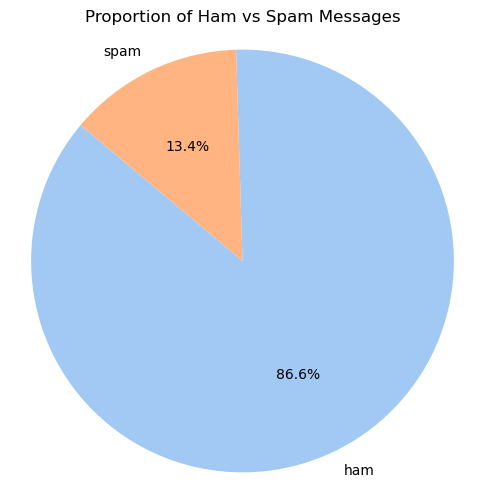

In [23]:
# Calculate class distribution
class_counts = df['label'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Proportion of Ham vs Spam Messages")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [ ]:
# The class distribution is imbalanced (87% ham, 13% spam) and should be carefully considered during model training.

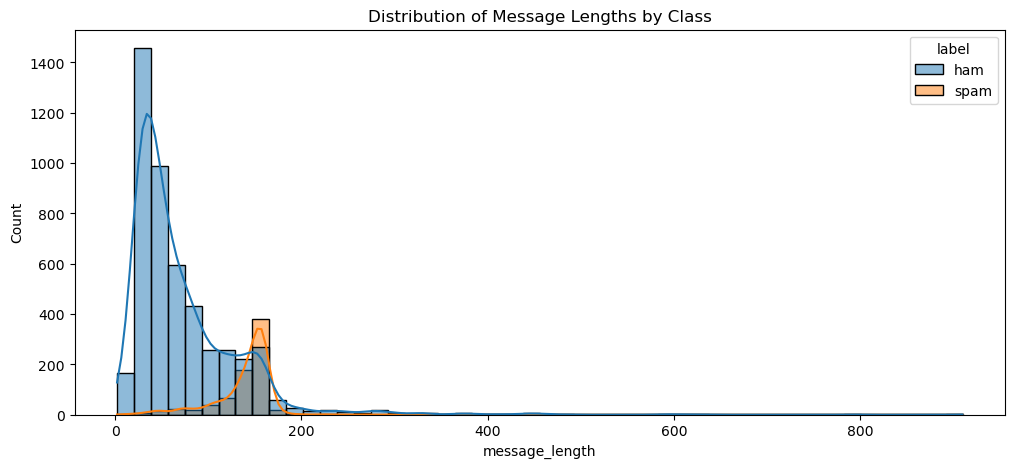

In [ ]:
# Message length analysis

df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True)
plt.title("Distribution of Message Lengths by Class")
plt.show()


In [ ]:
# The messages are generally short (under 200 characters), which is consistent with typical SMS length. 
# However, spam messages tend to be slightly longer on average compared to ham messages.

In [31]:
# Sample spams

# Display full sample spam messages without truncation
pd.set_option('display.max_colwidth', None)

# Show 5 full spam messages
sample_spams = df[df['label'] == 'spam']['message'].sample(5, random_state=42)
sample_spams.reset_index(drop=True, inplace=True)
sample_spams


0    Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
1         This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate 
2         Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just å£1.50 per wk 2 opt out send STOP 08452810071 16
3                          Ur cash-balance is currently 500 pounds - to maximize ur cash-in now send GO to 86688 only 150p/msg. CC: 08718720201 PO BOX 114/14 TCR/W1
4         Last Chance! Claim ur å£150 worth of discount vouchers today! Text SHOP to 85023 now! SavaMob, offers mobile! T Cs SavaMob POBOX84, M263UZ. å£3.00 Sub. 16
Name: message, dtype: object

In [32]:
# Sample hams

# Display full sample spam messages without truncation
pd.set_option('display.max_colwidth', None)

# Show 5 full spam messages
sample_spams = df[df['label'] == 'ham']['message'].sample(5, random_state=42)
sample_spams.reset_index(drop=True, inplace=True)
sample_spams

0                                                   I am late,so call you tomorrow morning.take care sweet dreams....u and me...ummifying...bye.
1                                                            U r too much close to my heart. If u go away i will be shattered. Plz stay with me.
2                                                                                                                         Wait  &lt;#&gt;  min..
3    Can you call me plz. Your number shows out of coveragd area. I have urgnt call in vasai &amp; have to reach before 4'o clock so call me plz
4                                                                              MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOULDN'T BE A PROBLEM.
Name: message, dtype: object

In [ ]:
# At first glance, the sampled spam and ham messages appear consistent with their labels, suggesting the dataset is well-annotated and reliable for training.

In [34]:
# Encode labels: ham → 0, spam → 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [36]:
# Save the cleaned DataFrame to CSV
output_path = "modified_src/cleaned_data.csv"
df.to_csv(output_path, index=False)

In [37]:
# Cleaned data are saved and message length had been included, we'll see later if it will be used.